# Comprehensive 2D Reconstruction Analysis (SVD Model)

This notebook provides a complete analysis of a 2D reconstruction run from the SVD Koopman model. It loads the `reconstruction_stats.npz` and timeseries files generated by `gen_reconstruction.py` to visualize:

1.  **Quantitative Metrics:** Overall and per-channel R² scores.
2.  **Error Plots:** R² bar charts and error-over-time plots.
3.  **Qualitative Visualizations:** Direct visual comparisons of ground truth, reconstructions, and errors, both as spatial snapshots and as time-evolution plots.

### 1. Setup and Imports

In [13]:
from pathlib import Path
import numpy as np
import logging
import matplotlib.pyplot as plt

# Ensure the mhd_surrogate_core package is in your PYTHONPATH
# These are the functions you provided in processed.py and evaluation.py
from mhd_surrogate_core.plotting.xz import (
    # Note: We re-use 'plot_prediction_rollout_error' to plot the per-step reconstruction error
    plot_prediction_rollout_error,
    plot_r2_performance,
    plot_xz_snapshot,
    plot_x_time_evolution,
    plot_z_time_evolution,
    plot_velocity_quiver
)

### 2. User Configuration

**Action Required:** Set your parameters in this cell. You must update `eval_output_dir` to point to the directory you specified in `run_reconstruction.sh`, and `ground_truth_path` to point to your test set.

In [14]:
# <<< 1. SET FILE PATHS >>>
# --- ACTION REQUIRED --- 
# Path to the directory where 'gen_reconstruction.py' saved its output
# This MUST match the --output-dir from your run_reconstruction.sh
eval_output_dir = Path("/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.0001_g_svdstab1e-05_bwd_False/eval/recon/")

# --- ACTION REQUIRED --- 
# Path to the original test set used for the evaluation
# This MUST match the --test-data-path from your run_reconstruction.sh
ground_truth_path = Path("/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/data/preprocessed_dns_output/01-Cold_Runs/01-Re16K_Ha325/T1492_x1151_y1_z127_c2/preprocessed/test_set.npz")

# <<< 2. DEFINE CHANNEL NAME MAPPING >>>
channel_map = {
    'vx': 'u',
    'vz': 'w'
}

# <<< 3. SET GLOBAL PLOT SIZING PARAMETERS >>>
global_base_size = 15
global_min_size = 3

# <<< 4. SET UNIT LABEL AND COLORMAPS >>>
global_unit_label = ""
main_cmap = "seismic"      # For ground truth and reconstruction
diff_cmap = "seismic"      # For difference plots (blue-white-red is good for errors)
magnitude_cmap = 'inferno' # For magnitude quiver plots
diff_magnitude_cmap = 'Reds' # For quiver plot of the difference field

# <<< 5. SET COLOR SCALES FOR MAIN PLOTS (OPTIONAL) >>>
# If a value is not set here, it will be auto-calculated from the data.
main_vmins = {
    'vx': -2.16,
    'vz': -3.0,
}
main_vmaxs = {
    'vx': 3.84,
    'vz': 3.0,
}
main_vcenters = {
    'vx': 0.84,
    'vz': 0.0
}

# <<< 6. SET COLOR SCALES FOR DIFFERENCE PLOTS (OPTIONAL) >>>
# It's often best to center difference plots at 0.
diff_vmins = {
    'vx': -3.0,
    'vz': -3.0,
}
diff_vmaxs = {
    'vx': 3.0,
    'vz': 3.0,
}
diff_vcenters = {
    'vx': 0.0,
    'vz': 0.0
}

# <<< 7. SET MEAN FLOW FOR QUIVER PLOT (OPTIONAL) >>>
global_mean_flow = {
    'vx': 0.84
}

print("Configuration set. You can now run the 'Load Data' cell.")

Configuration set. You can now run the 'Load Data' cell.


### 3. Load Data

**Run this cell only once** at the beginning of your session or after changing the file paths above.

In [15]:
# --- DATA LOADING LOGIC ---
stats_file_path = eval_output_dir / "reconstruction_stats.npz"
reconstructed_file_path = eval_output_dir / "reconstructed_timeseries.npz"
difference_file_path = eval_output_dir / "difference_timeseries.npz"

if not all([p.exists() for p in [stats_file_path, reconstructed_file_path, difference_file_path, ground_truth_path]]):
    logging.error("ERROR: One or more data files not found. Please check the paths in Cell 2.")
    print(f"Missing: {stats_file_path}" if not stats_file_path.exists() else "")
    print(f"Missing: {reconstructed_file_path}" if not reconstructed_file_path.exists() else "")
    print(f"Missing: {difference_file_path}" if not difference_file_path.exists() else "")
    print(f"Missing: {ground_truth_path}" if not ground_truth_path.exists() else "")
else:
    with np.load(stats_file_path, allow_pickle=True) as data:
        r_squared_total = data['r_squared_total']
        channel_names = list(data['channel_names'])
        print(f"Loaded statistics from {stats_file_path}")
    
    with np.load(reconstructed_file_path, allow_pickle=True) as data:
        reconstructed_timeseries = data['timeseries']
        print(f"Loaded reconstructed timeseries from {reconstructed_file_path}")

    with np.load(difference_file_path, allow_pickle=True) as data:
        difference_timeseries = data['timeseries']
        print(f"Loaded difference timeseries from {difference_file_path}")
        
    with np.load(ground_truth_path, allow_pickle=True) as data:
        ground_truth_timeseries_all = data['timeseries']
        all_labels = list(data['labels'])
        if ground_truth_timeseries_all.ndim == 5:
            ground_truth_timeseries_all = np.squeeze(ground_truth_timeseries_all, axis=2)
        coords = {
            'x': data.get('x_coords', np.arange(ground_truth_timeseries_all.shape[1])),
            'z': data.get('z_coords', np.arange(ground_truth_timeseries_all.shape[2])),
            'labels': all_labels # Use all labels for indexing
        }
        print(f"Loaded ground truth from {ground_truth_path}")
    
    # Filter ground truth to only include channels the model was trained on
    gt_indices = [all_labels.index(name) for name in channel_names]
    ground_truth_timeseries = ground_truth_timeseries_all[..., gt_indices]
    # IMPORTANT: Update coords to match the filtered data
    coords['labels'] = channel_names
    print(f"Filtered ground truth to match reconstructed channels: {channel_names}")
    
    # Check that shapes match
    if ground_truth_timeseries.shape[0] < reconstructed_timeseries.shape[0]:
        print(f"Warning: Ground truth ({ground_truth_timeseries.shape[0]}) is shorter than reconstruction ({reconstructed_timeseries.shape[0]}). Truncating reconstruction.")
        T = ground_truth_timeseries.shape[0]
        reconstructed_timeseries = reconstructed_timeseries[:T]
        difference_timeseries = difference_timeseries[:T]
    elif reconstructed_timeseries.shape[0] < ground_truth_timeseries.shape[0]:
        print(f"Warning: Reconstruction ({reconstructed_timeseries.shape[0]}) is shorter than ground truth ({ground_truth_timeseries.shape[0]}). Truncating ground truth.")
        T = reconstructed_timeseries.shape[0]
        ground_truth_timeseries = ground_truth_timeseries[:T]
        difference_timeseries = difference_timeseries[:T]
    
    if ground_truth_timeseries.shape != reconstructed_timeseries.shape:
        logging.error(f"FATAL: Shapes still do not match! GT: {ground_truth_timeseries.shape}, Recon: {reconstructed_timeseries.shape}")
    else:
        print(f"Data loaded and aligned. Final shape: {ground_truth_timeseries.shape}")

    max_time_index = reconstructed_timeseries.shape[0] - 1
    max_x_index = reconstructed_timeseries.shape[1] - 1
    max_z_index = reconstructed_timeseries.shape[2] - 1
    print(f"\nMax indices -> Time: {max_time_index}, X: {max_x_index}, Z: {max_z_index}")
    
    velocity_components = sorted([c for c in coords.get('labels', []) if c in channel_map])
    print(f"Identified velocity components to plot: {velocity_components}")

Loaded statistics from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.0001_g_svdstab1e-05_bwd_False/eval/recon/reconstruction_stats.npz
Loaded reconstructed timeseries from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.0001_g_svdstab1e-05_bwd_False/eval/recon/reconstructed_timeseries.npz
Loaded difference timeseries from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.00

---

### 4. Quantitative Analysis

2025-11-06 20:39:20,488 - INFO - Loading R² performance from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.0001_g_svdstab1e-05_bwd_False/eval/recon/reconstruction_stats.npz...


--- RECONSTRUCTION SUMMARY ---
Overall R² Score: 0.9534


--- Average Reconstruction Performance (R²) ---


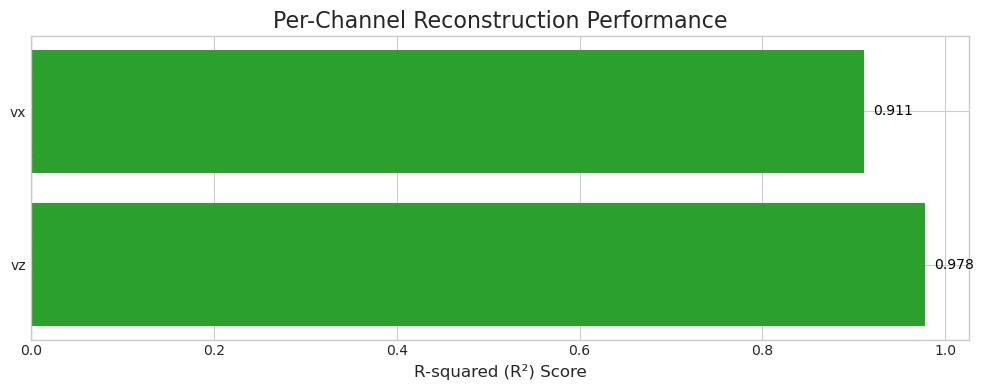

2025-11-06 20:39:20,605 - INFO - Loading prediction rollout error from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_5_low_rank_tckae_2d/study_5.2_stable_svd/output/force_recon/force_recon_K16_val16_koop16/flat_kr16_M1_K16_Ktc0_gtc0_gi10000.0_gfwd1.0_g_svdo0.0001_g_svdstab1e-05_bwd_False/eval/recon/reconstruction_stats.npz...



--- Reconstruction Error Over Time ---


/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/packages/mhd_surrogate_core/src/mhd_surrogate_core/plotting/xz/evaluation.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


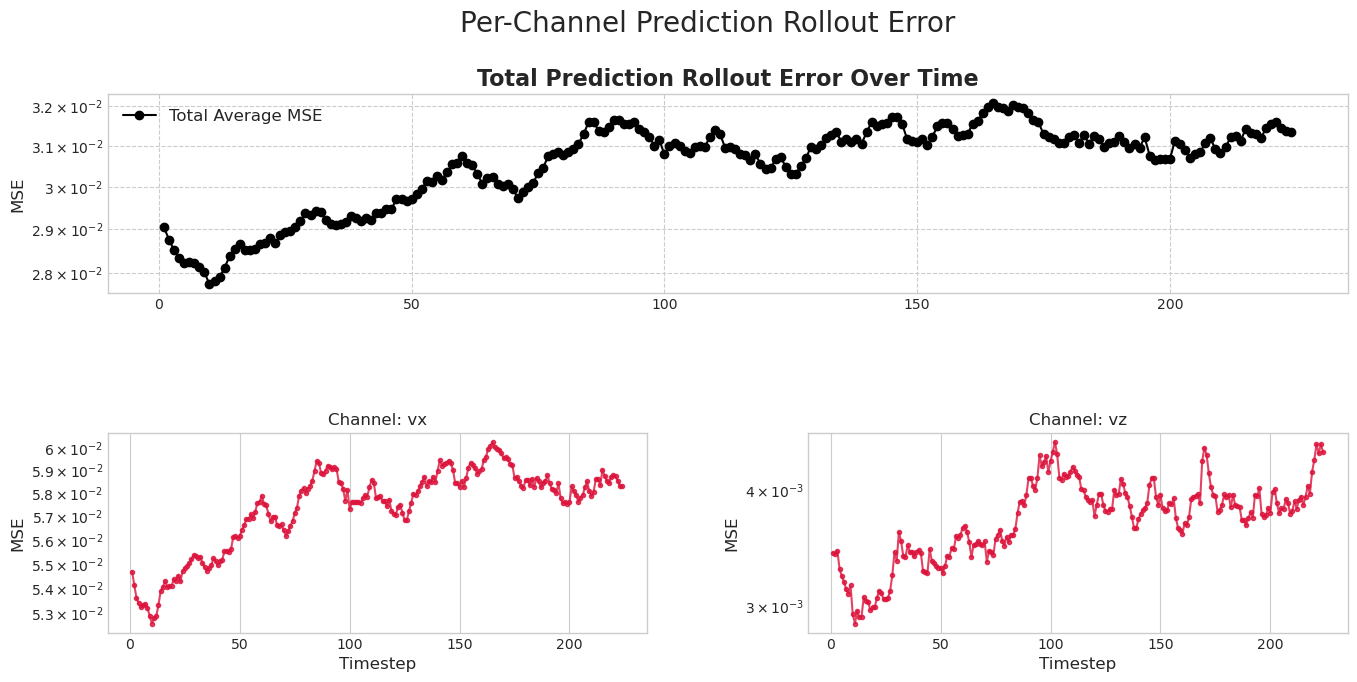

In [16]:
print(f"--- RECONSTRUCTION SUMMARY ---")
print(f"Overall R² Score: {r_squared_total:.4f}\n")

print("\n--- Average Reconstruction Performance (R²) ---")
plot_r2_performance(stats_file_path, eval_type="Reconstruction")

print("\n--- Reconstruction Error Over Time ---")
# This plot will load 'per_step_channel_error' from the stats file
plot_prediction_rollout_error(stats_file_path)

---

### 5. Qualitative Analysis: Spatial Snapshots

This section compares the ground truth, reconstruction, and error for a single snapshot in time.

In [17]:
# === Parameters for 2D Snapshots ===
# <<< MODIFY THESE VALUES >>>
plot_time_index = 16
quiver_downsample_stride = 15
quiver_arrow_width = 0.0025
# ---
if plot_time_index > max_time_index:
    plot_time_index = max_time_index
    print(f"Warning: plot_time_index too large. Clamping to {max_time_index}.")
print(f"Using time-index {plot_time_index} for snapshot plots.")

Using time-index 16 for snapshot plots.


#### 5.1 Velocity Field Quiver Plot Comparison

Shared quiver color scale (fluctuations): [0.000, 3.630]


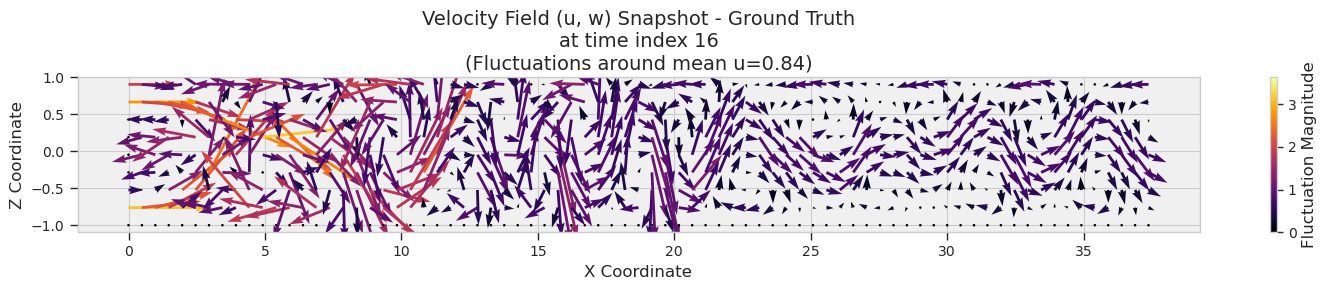

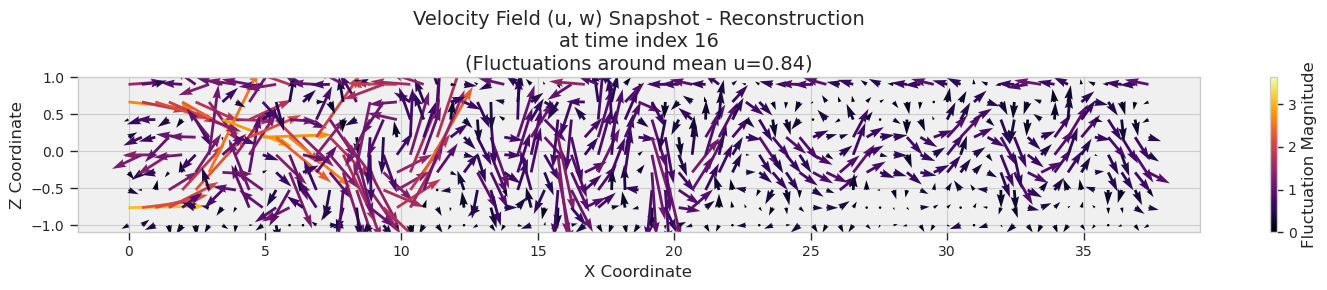

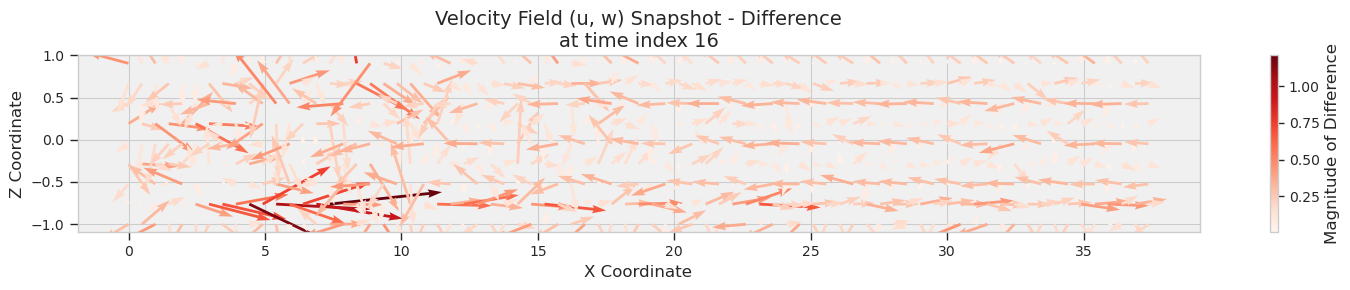

In [18]:
# === Plot Quiver Comparison ===
if 'vx' in velocity_components and 'vz' in velocity_components:
    # --- 1. Calculate shared color scale for truth and reconstruction fluctuations ---
    vx_idx = coords['labels'].index('vx')
    vz_idx = coords['labels'].index('vz')
    mean_u = global_mean_flow.get('vx', 0.0)
    mean_v = global_mean_flow.get('vz', 0.0)

    # Helper to calculate fluctuation magnitude
    def get_fluctuation_magnitude(timeseries):
        u_fluc = timeseries[plot_time_index, :, :, vx_idx].copy()
        v_fluc = timeseries[plot_time_index, :, :, vz_idx].copy()
        if u_fluc.shape[0] > 2 and u_fluc.shape[1] > 2: u_fluc[1:-1, 1:-1] -= mean_u
        if v_fluc.shape[0] > 2 and v_fluc.shape[1] > 2: v_fluc[1:-1, 1:-1] -= mean_v
        return np.sqrt(u_fluc**2 + v_fluc**2)
    
    gt_mag = get_fluctuation_magnitude(ground_truth_timeseries)
    recon_mag = get_fluctuation_magnitude(reconstructed_timeseries)
    
    quiver_vmin = min(gt_mag.min(), recon_mag.min())
    quiver_vmax = max(gt_mag.max(), recon_mag.max())
    print(f"Shared quiver color scale (fluctuations): [{quiver_vmin:.3f}, {quiver_vmax:.3f}]")

    # --- 2. Plot Ground Truth Quiver ---
    plot_velocity_quiver(
        data_path=None, timeseries_data=ground_truth_timeseries, coords=coords,
        time_index=plot_time_index, u_channel='vx', v_channel='vz',
        channel_alias_map=channel_map, mean_flow_components=globals().get('global_mean_flow'),
        vmin=quiver_vmin, vmax=quiver_vmax, base_size=global_base_size, min_size=global_min_size,
        unit_label=global_unit_label, cmap=magnitude_cmap, quiver_stride=quiver_downsample_stride,
        arrow_width=quiver_arrow_width, title_suffix="Ground Truth"
    )

    # --- 3. Plot Reconstruction Quiver ---
    plot_velocity_quiver(
        data_path=None, timeseries_data=reconstructed_timeseries, coords=coords,
        time_index=plot_time_index, u_channel='vx', v_channel='vz',
        channel_alias_map=channel_map, mean_flow_components=globals().get('global_mean_flow'),
        vmin=quiver_vmin, vmax=quiver_vmax, base_size=global_base_size, min_size=global_min_size,
        unit_label=global_unit_label, cmap=magnitude_cmap, quiver_stride=quiver_downsample_stride,
        arrow_width=quiver_arrow_width, title_suffix="Reconstruction"
    )

    # --- 4. Plot Difference Quiver ---
    cbar_label = "Magnitude of Difference" + (f" [{global_unit_label}]" if global_unit_label else "")
    plot_velocity_quiver(
        data_path=None, timeseries_data=difference_timeseries, coords=coords,
        time_index=plot_time_index, u_channel='vx', v_channel='vz',
        channel_alias_map=channel_map, mean_flow_components=None, # Plot raw difference
        base_size=global_base_size, min_size=global_min_size, unit_label=global_unit_label,
        cmap=diff_magnitude_cmap, quiver_stride=quiver_downsample_stride,
        arrow_width=quiver_arrow_width, title_suffix="Difference",
        cbar_label_override=cbar_label
    )

#### 5.2 Individual Component Snapshots

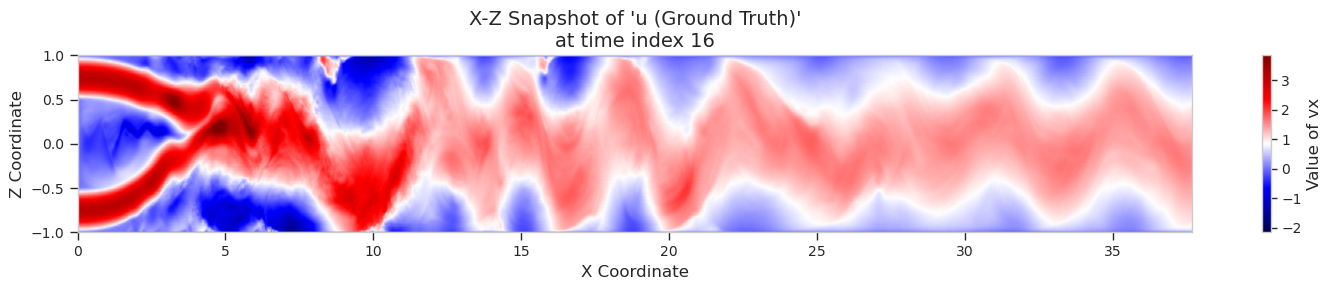

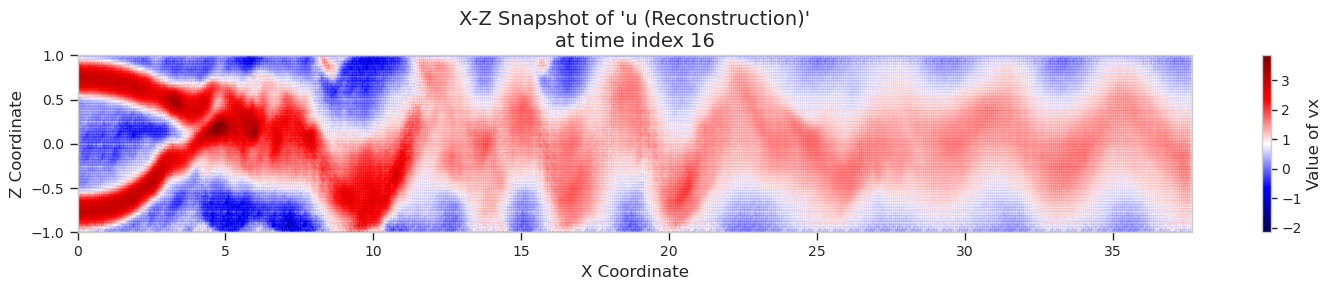

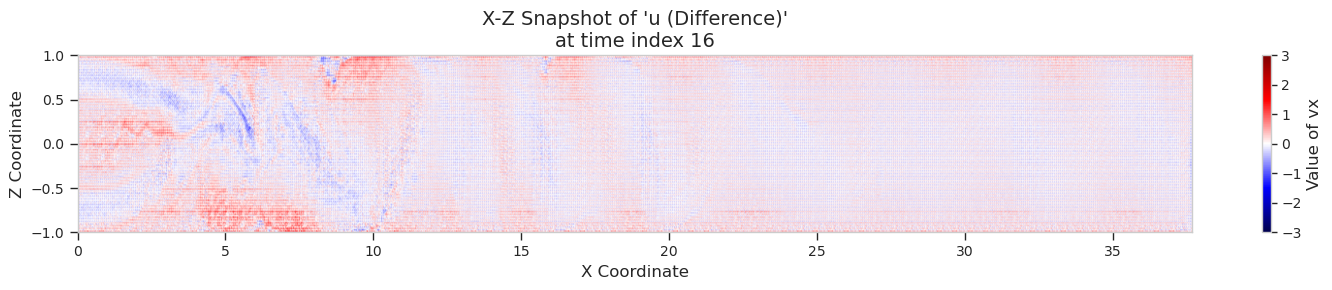

In [19]:
# === Plot Snapshot Comparison for u (vx) ===
if 'vx' in velocity_components:
    # Calculate shared color scale for truth and reconstruction, unless overridden
    vmin = main_vmins.get('vx')
    vmax = main_vmaxs.get('vx')
    if vmin is None or vmax is None:
        vx_idx = coords['labels'].index('vx')
        gt_slice = ground_truth_timeseries[plot_time_index, :, :, vx_idx]
        recon_slice = reconstructed_timeseries[plot_time_index, :, :, vx_idx]
        auto_vmin = min(gt_slice.min(), recon_slice.min())
        auto_vmax = max(gt_slice.max(), recon_slice.max())
        if vmin is None: vmin = auto_vmin
        if vmax is None: vmax = auto_vmax

    # Ground Truth
    plot_xz_snapshot(data_path=None, timeseries_data=ground_truth_timeseries, coords=coords, channel='vx',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vx')} (Ground Truth)",
                     vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size,
                     min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    # Reconstruction
    plot_xz_snapshot(data_path=None, timeseries_data=reconstructed_timeseries, coords=coords, channel='vx',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vx')} (Reconstruction)",
                     vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size, 
                     min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    # Difference
    plot_xz_snapshot(data_path=None, timeseries_data=difference_timeseries, coords=coords, channel='vx',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vx')} (Difference)",
                     vmin=diff_vmins.get('vx'), vmax=diff_vmaxs.get('vx'), vcenter=diff_vcenters.get('vx'), 
                     base_size=global_base_size, min_size=global_min_size, unit_label=global_unit_label, cmap=diff_cmap)

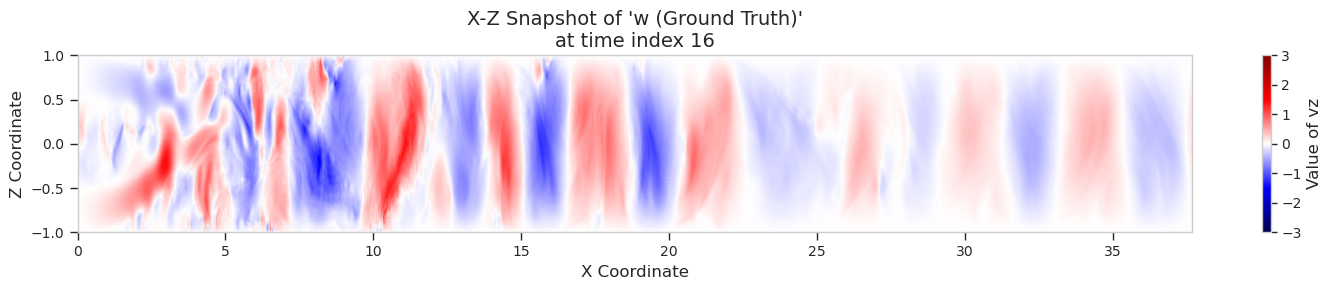

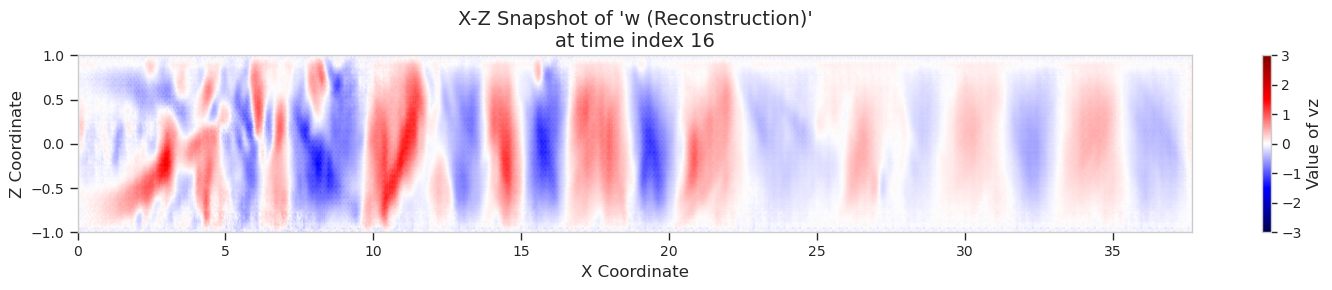

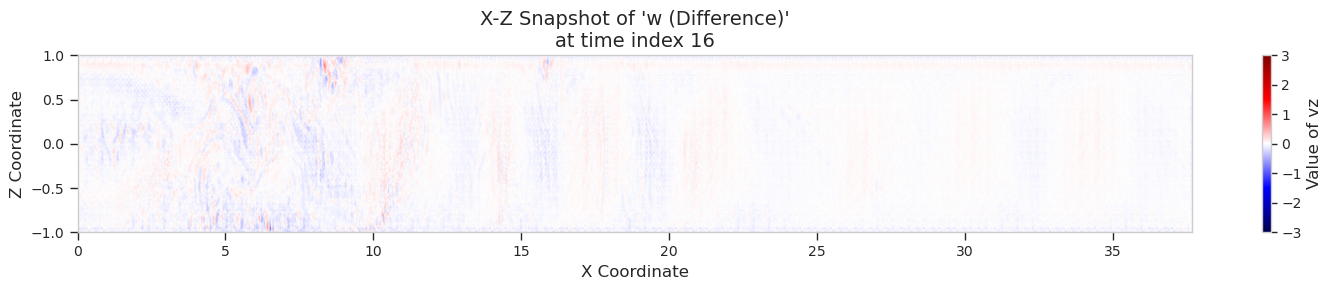

In [20]:
# === Plot Snapshot Comparison for w (vz) ===
if 'vz' in velocity_components:
    vmin = main_vmins.get('vz')
    vmax = main_vmaxs.get('vz')
    if vmin is None or vmax is None:
        vz_idx = coords['labels'].index('vz')
        gt_slice = ground_truth_timeseries[plot_time_index, :, :, vz_idx]
        recon_slice = reconstructed_timeseries[plot_time_index, :, :, vz_idx]
        auto_vmin = min(gt_slice.min(), recon_slice.min())
        auto_vmax = max(gt_slice.max(), recon_slice.max())
        if vmin is None: vmin = auto_vmin
        if vmax is None: vmax = auto_vmax

    plot_xz_snapshot(data_path=None, timeseries_data=ground_truth_timeseries, coords=coords, channel='vz',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vz')} (Ground Truth)",
                     vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vz'), base_size=global_base_size,
                     min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_xz_snapshot(data_path=None, timeseries_data=reconstructed_timeseries, coords=coords, channel='vz',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vz')} (Reconstruction)",
                     vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vz'), base_size=global_base_size, 
                     min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_xz_snapshot(data_path=None, timeseries_data=difference_timeseries, coords=coords, channel='vz',
                     time_index=plot_time_index, channel_alias=f"{channel_map.get('vz')} (Difference)",
                     vmin=diff_vmins.get('vz'), vmax=diff_vmaxs.get('vz'), vcenter=diff_vcenters.get('vz'), 
                     base_size=global_base_size, min_size=global_min_size, unit_label=global_unit_label, cmap=diff_cmap)

---

### 6. Qualitative Analysis: Time Evolution

#### 6.1 Evolution along Z-axis (at constant X)

In [21]:
# === Parameters for Time-Z Plots ===
# <<< MODIFY THESE VALUES >>>
plot_x_index_tz = 1000
# ---
if plot_x_index_tz > max_x_index:
    plot_x_index_tz = max_x_index
    print(f"Warning: plot_x_index_tz too large. Clamping to {max_x_index}.")
print(f"Using x-index {plot_x_index_tz} for Time-Z plots.")

Using x-index 1000 for Time-Z plots.


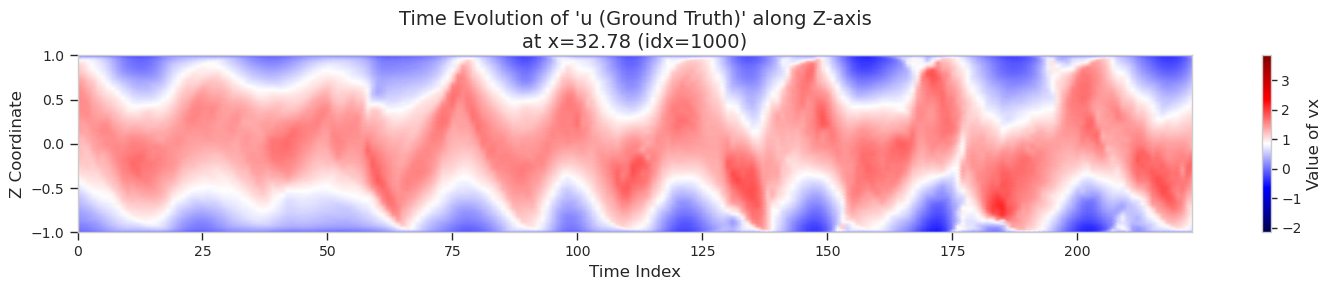

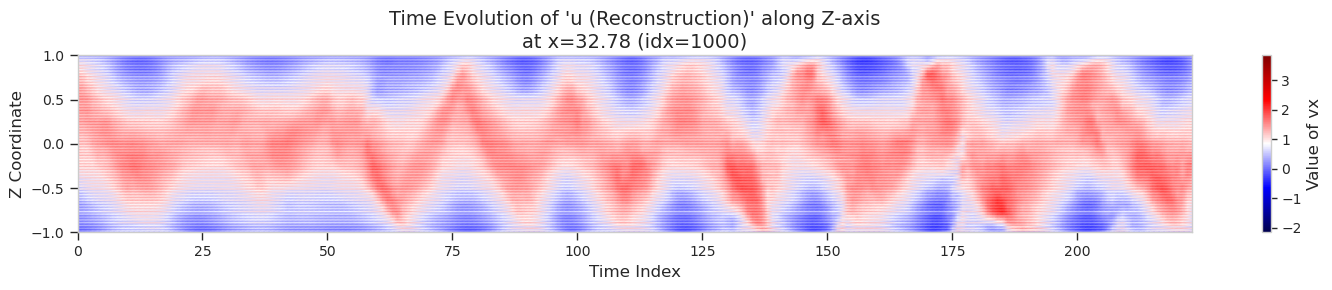

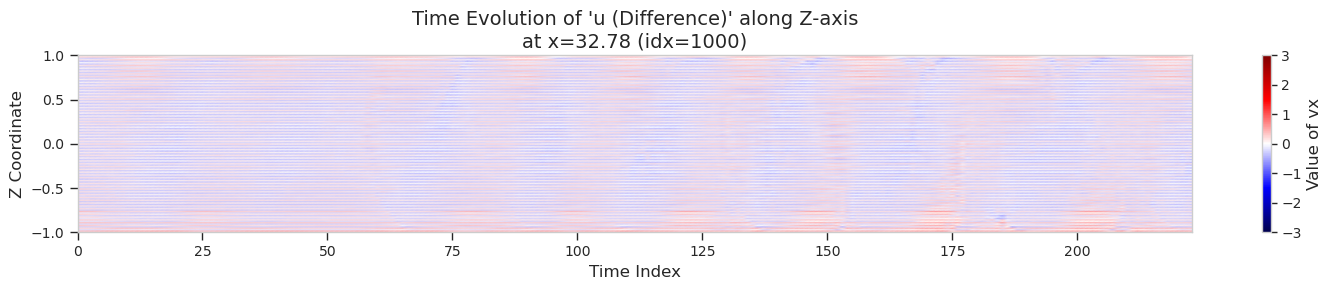

In [22]:
# === Plot Time-Z Evolution for u (vx) ===
if 'vx' in velocity_components:
    vmin = main_vmins.get('vx')
    vmax = main_vmaxs.get('vx')
    if vmin is None or vmax is None:
        vx_idx = coords['labels'].index('vx')
        gt_slice = ground_truth_timeseries[:, plot_x_index_tz, :, vx_idx]
        recon_slice = reconstructed_timeseries[:, plot_x_index_tz, :, vx_idx]
        auto_vmin = min(gt_slice.min(), recon_slice.min())
        auto_vmax = max(gt_slice.max(), recon_slice.max())
        if vmin is None: vmin = auto_vmin
        if vmax is None: vmax = auto_vmax

    plot_z_time_evolution(data_path=None, timeseries_data=ground_truth_timeseries, coords=coords, channel='vx',
                          x_index=plot_x_index_tz, channel_alias=f"{channel_map.get('vx')} (Ground Truth)",
                          vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size,
                          min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_z_time_evolution(data_path=None, timeseries_data=reconstructed_timeseries, coords=coords, channel='vx',
                          x_index=plot_x_index_tz, channel_alias=f"{channel_map.get('vx')} (Reconstruction)",
                          vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size,
                          min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_z_time_evolution(data_path=None, timeseries_data=difference_timeseries, coords=coords, channel='vx',
                          x_index=plot_x_index_tz, channel_alias=f"{channel_map.get('vx')} (Difference)",
                          vmin=diff_vmins.get('vx'), vmax=diff_vmaxs.get('vx'), vcenter=diff_vcenters.get('vx'),
                          base_size=global_base_size, min_size=global_min_size, unit_label=global_unit_label, cmap=diff_cmap)

#### 6.2 Evolution along X-axis (at constant Z)

In [23]:
# === Parameters for Time-X Plots ===
# <<< MODIFY THESE VALUES >>>
plot_z_index_tx = 8
# ---
if plot_z_index_tx > max_z_index:
    plot_z_index_tx = max_z_index
    print(f"Warning: plot_z_index_tx too large. Clamping to {max_z_index}.")
print(f"Using z-index {plot_z_index_tx} for Time-X plots.")

Using z-index 8 for Time-X plots.


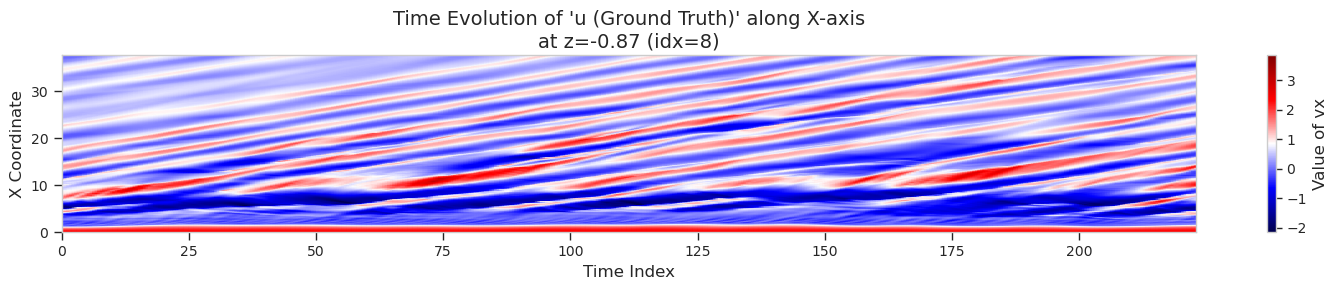

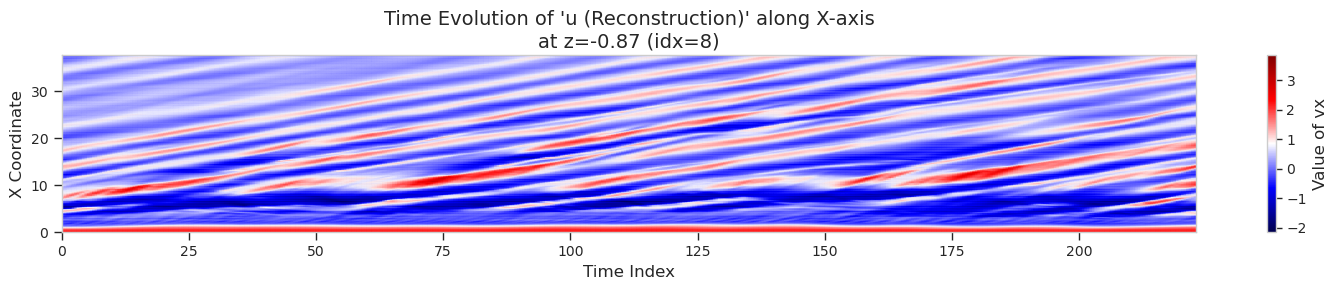

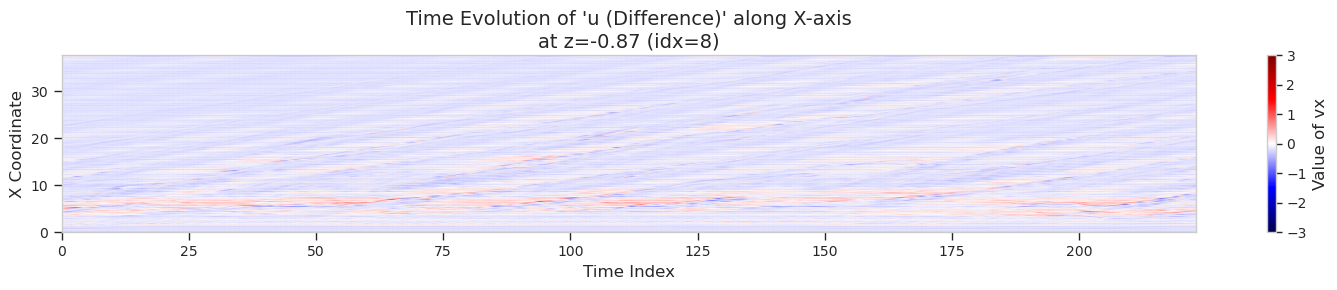

In [24]:
# === Plot Time-X Evolution for u (vx) ===
if 'vx' in velocity_components:
    vmin = main_vmins.get('vx')
    vmax = main_vmaxs.get('vx')
    if vmin is None or vmax is None:
        vx_idx = coords['labels'].index('vx')
        gt_slice = ground_truth_timeseries[:, :, plot_z_index_tx, vx_idx]
        recon_slice = reconstructed_timeseries[:, :, plot_z_index_tx, vx_idx]
        auto_vmin = min(gt_slice.min(), recon_slice.min())
        auto_vmax = max(gt_slice.max(), recon_slice.max())
        if vmin is None: vmin = auto_vmin
        if vmax is None: vmax = auto_vmax

    plot_x_time_evolution(data_path=None, timeseries_data=ground_truth_timeseries, coords=coords, channel='vx',
                          z_index=plot_z_index_tx, channel_alias=f"{channel_map.get('vx')} (Ground Truth)",
                          vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size,
                          min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_x_time_evolution(data_path=None, timeseries_data=reconstructed_timeseries, coords=coords, channel='vx',
                          z_index=plot_z_index_tx, channel_alias=f"{channel_map.get('vx')} (Reconstruction)",
                          vmin=vmin, vmax=vmax, vcenter=main_vcenters.get('vx'), base_size=global_base_size,
                          min_size=global_min_size, unit_label=global_unit_label, cmap=main_cmap)
    plot_x_time_evolution(data_path=None, timeseries_data=difference_timeseries, coords=coords, channel='vx',
                          z_index=plot_z_index_tx, channel_alias=f"{channel_map.get('vx')} (Difference)",
                          vmin=diff_vmins.get('vx'), vmax=diff_vmaxs.get('vx'), vcenter=diff_vcenters.get('vx'),
                          base_size=global_base_size, min_size=global_min_size, unit_label=global_unit_label, cmap=diff_cmap)